# PRISIGHT — Notebook 2  
# Comparative Deep Learning Analysis for Retail Demand Forecasting  
## LSTM vs Transformer Architecture

### Final Year MCA Project Extension and Analytical Study

**Made By:** Avinandan Bhattacharjee  
**Program:** *MCA 2026, Techno India University*  
**Under the Guidance of:** *Dr. Jayanta Datta, Professor, Techno India University*

---

# 1. Introduction

This notebook represents the second analytical extension of the Prisight forecasting framework and focuses on comparative deep learning analysis between recurrent neural architectures and Transformer-based sequence modeling for retail demand forecasting.

The primary objective of this notebook is to evaluate and compare:

- Long Short-Term Memory (LSTM)
- Transformer Architecture

for intelligent retail demand forecasting using long sequential time-series data.

The notebook investigates how Transformer-based attention mechanisms perform against traditional recurrent sequence learning methods in capturing:

- long-term demand dependencies,
- temporal trends,
- seasonal fluctuations,
- cyclic sales behavior,
- demand momentum,
- and future forecasting continuity.

This notebook extends the recurrent forecasting analysis performed in Notebook 1 and introduces attention-driven sequence learning into the Prisight ecosystem.

---

# 2. Objectives of Notebook 2

The notebook is designed to:

1. Extend Project Prisight using Transformer-based forecasting
2. Compare recurrent and attention-based architectures
3. Analyze long-sequence forecasting behavior
4. Evaluate Transformer attention learning for demand prediction
5. Compare forecasting stability between LSTM and Transformer
6. Measure forecasting performance using multiple evaluation metrics
7. Study future sequential prediction continuity

---

# 3. Dataset Overview

The forecasting implementation uses long-term synthetic retail demand data generated for advanced sequential forecasting analysis.

The generated dataset includes:

- daily product sales,
- trend continuation,
- seasonal demand patterns,
- discount-driven variations,
- cyclic weekday behavior,
- rolling demand statistics,
- and pricing influence.

The dataset is designed to simulate realistic retail forecasting conditions for deep learning sequence models.

---

# 4. Features Used for Forecasting

The forecasting models use engineered temporal and business features including:

| Feature Name | Purpose |
|---|---|
| `units_sold` | Target demand variable |
| `lag_1` | Previous day sales |
| `lag_7` | Previous week sales |
| `rolling_avg_7` | Weekly demand average |
| `price_ratio` | Selling vs market price relationship |
| `discount_percent` | Promotional pricing effect |
| `discount_effect` | Elasticity-driven demand response |
| `is_weekend` | Weekend sales indicator |
| `weekday_sin`, `weekday_cos` | Cyclic weekday encoding |
| `month_sin`, `month_cos` | Seasonal cyclic encoding |
| `demand_trend` | Rolling demand momentum |

---

# 5. Notebook Structure

---

## Part 1 — Environment Setup and Library Import

This section imports all required libraries and initializes the forecasting environment.

### Major Libraries Used

```python
numpy
pandas
tensorflow
keras
matplotlib
sklearn
```

---

## Part 2 — Synthetic Retail Demand Data Generation

This section generates long-term retail sales sequences with:

- trend movement,
- seasonal fluctuations,
- cyclic demand behavior,
- and discount influence.

### Important Functions

```python
generate_synthetic_sales_data()
np.sin()
np.random.normal()
```

---

## Part 3 — Feature Engineering and Sequence Preparation

This section prepares the data for deep sequential learning.

### Operations Performed

- lag generation,
- rolling statistics,
- cyclic encoding,
- normalization,
- and sequence window creation.

### Important Parameters

```python
WINDOW_SIZE = 30
TRAIN_SPLIT = 0.8
```

---

## Part 4 — LSTM Forecasting Architecture

This section implements the recurrent LSTM forecasting network.

### Architecture Overview

```text
LSTM → Dropout → LSTM → Dense Layers
```

### Purpose

To capture long-term sequential dependencies in retail demand forecasting.

---

## Part 5 — Transformer Forecasting Architecture

This section introduces Transformer-based sequence forecasting using attention mechanisms.

### Architecture Overview

```text
Input Embedding → Multi-Head Attention
                 → Feed Forward Network
                 → Layer Normalization
                 → Dense Output Layer
```

### Important Components Used

```python
MultiHeadAttention()
LayerNormalization()
Dense()
Dropout()
```

### Purpose

To evaluate attention-driven sequence learning for long-term retail forecasting.

---

## Part 6 — Model Training and Evaluation

This section trains both architectures and evaluates forecasting performance.

### Evaluation Metrics Used

| Metric | Purpose |
|---|---|
| RMSE | Forecast error magnitude |
| MAE | Average absolute error |
| MAPE | Percentage forecasting error |
| R² Score | Prediction fit quality |

### Visualization Performed

- Actual vs Predicted Curves
- Residual Analysis
- Scatter Comparisons
- Forecast Overlays
- Comparative Model Graphs

---

## Part 7 — Future Demand Forecasting

This section performs rolling-window sequential forecasting for future demand prediction.

### Forecast Horizon

```python
7-Day Sequential Forecasting
```

### Important Functions

```python
forecast_future()
inverse_transform()
```

---

# 6. Important Training Parameters

| Parameter | Value |
|---|---|
| Window Size | 30 |
| Optimizer | Adam |
| Loss Function | Mean Squared Error |
| Epochs | 300 |
| Batch Size | 16 |
| Learning Rate | 0.001 |
| Dropout | 0.2 |

---

# 7. Logical Comparison Between Architectures

| Architecture | Advantages | Drawbacks |
|---|---|---|
| LSTM | Strong sequential memory learning | Slower parallel computation |
| Transformer | Better long-range dependency learning using attention | Higher computational complexity |
| LSTM | Stable for medium-length sequences | Sequential processing limits speed |
| Transformer | Parallel sequence processing capability | Requires larger data for optimal learning |

---

# 8. Comparative Architectural Analysis

| Feature | LSTM | Transformer |
|---|---|---|
| Sequential Learning | Excellent | Excellent |
| Long-Term Dependency Handling | Strong | Very Strong |
| Parallel Computation | Limited | Excellent |
| Computational Cost | Medium | High |
| Training Speed | Moderate | Faster on parallel hardware |
| Attention Mechanism | No | Yes |
| Sequence Context Learning | Good | Excellent |
| Scalability | Moderate | High |

---

# 9. Key Functions Used in the Notebook

| Function | Purpose |
|---|---|
| `create_sequences()` | Converts data into sequential windows |
| `build_lstm_model()` | Creates LSTM architecture |
| `build_transformer_model()` | Creates Transformer architecture |
| `forecast_future()` | Generates rolling future forecasts |
| `MultiHeadAttention()` | Transformer attention learning |
| `LayerNormalization()` | Stabilizes Transformer training |
| `EarlyStopping()` | Prevents overfitting |
| `model.fit()` | Model training |
| `model.predict()` | Forecast generation |

---

# 10. Purpose of Notebook 2 within Prisight

Notebook 2 introduces attention-based forecasting architectures into the Prisight ecosystem and extends the recurrent forecasting analysis performed in Notebook 1.

The notebook establishes a comparative framework between:

- recurrent neural sequence learning,
- and Transformer-based attention learning

for intelligent retail demand forecasting applications.

---

---
# ═══════════════════════════════════════
# PART 1 — LSTM MODEL
# ═══════════════════════════════════════

## 1. Setup and Imports

In [1]:
!pip install tensorflow numpy pandas scikit-learn matplotlib seaborn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Add, Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

np.random.seed(42)
tf.random.set_seed(42)
print('Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

Libraries imported successfully!
TensorFlow version: 2.20.0


## 2. Generate Dataset

In [3]:
def generate_test_dataset(n_products=4, n_days=500, start_date='2024-01-01'):
    """
    v4 data generation — unchanged from lstm_vs_gru_v4.
    Key properties:
      - 500 days × 4 products → richer training sequences
      - variance=1.5  (good signal-to-noise ratio)
      - weekend effect 1.70×  (strong, learnable weekend spike)
      - seasonality amplitude 0.40  (pronounced monthly cycle)
      - sin/cos cyclic encoding for weekday & month
    """
    product_configs = {
        1: {'base_price': 11999, 'base_demand': 12, 'variance': 1.5, 'elasticity': 1.2},
        2: {'base_price':   699, 'base_demand':  6, 'variance': 0.8, 'elasticity': 1.8},
        3: {'base_price':  2499, 'base_demand':  4, 'variance': 0.7, 'elasticity': 1.0},
        4: {'base_price':  6799, 'base_demand': 10, 'variance': 1.2, 'elasticity': 1.4},
    }
    dates = pd.date_range(start=start_date, periods=n_days, freq='D')
    all_records = []

    for product_id, config in product_configs.items():
        for i, date in enumerate(dates):
            weekday = date.weekday(); month = date.month
            selling_price    = config['base_price'] * np.random.uniform(0.97, 1.03)
            market_avg_price = config['base_price'] * np.random.uniform(0.93, 1.07)
            discount_percent = np.random.uniform(0, 30)
            is_weekend       = 1 if weekday >= 5 else 0
            weekday_effect   = 1.70 if is_weekend else 1.0
            monthly_season   = 1.0 + 0.40 * np.sin((month - 3) * np.pi / 6)
            trend            = 1.0 + (i / n_days) * 0.20
            discount_effect  = 1.0 + config['elasticity'] * (discount_percent / 100)
            price_ratio      = np.clip(market_avg_price / selling_price, 0.85, 1.20)
            base = (config['base_demand'] * weekday_effect * monthly_season
                    * trend * discount_effect * price_ratio)
            noise = np.random.normal(0, config['variance'])
            units_sold = max(1, int(base + noise))
            all_records.append({
                'product_id': product_id, 'date': date,
                'units_sold': units_sold,
                'selling_price': round(selling_price, 2),
                'market_avg_price': round(market_avg_price, 2),
                'discount_percent': round(discount_percent, 2),
                'weekday': weekday, 'month': month, 'is_weekend': is_weekend,
                'price_ratio': round(price_ratio, 4),
                'discount_effect': round(discount_effect, 4),
                'weekday_sin': np.sin(2*np.pi*weekday/7),
                'weekday_cos': np.cos(2*np.pi*weekday/7),
                'month_sin':   np.sin(2*np.pi*(month-1)/12),
                'month_cos':   np.cos(2*np.pi*(month-1)/12),
            })

    df = pd.DataFrame(all_records)

    for pid in product_configs:
        mask = df['product_id'] == pid
        s = df.loc[mask, 'units_sold']
        df.loc[mask, 'rolling_avg_7']  = s.rolling(7,  min_periods=1).mean()
        df.loc[mask, 'rolling_avg_14'] = s.rolling(14, min_periods=1).mean()
        df.loc[mask, 'rolling_avg_30'] = s.rolling(30, min_periods=1).mean()
        df.loc[mask, 'lag_1']          = s.shift(1).fillna(s.mean())
        df.loc[mask, 'lag_7']          = s.shift(7).fillna(s.mean())
        df.loc[mask, 'demand_trend']   = (
            s.rolling(7, min_periods=1).mean()
            - s.rolling(14, min_periods=2).mean()
        ).fillna(0)
    return df

df = generate_test_dataset(n_products=4, n_days=500, start_date='2024-01-01')
df.to_csv('lstm_transformer_dataset.csv', index=False)

print('='*60)
print('DATASET GENERATED — 500 days × 4 products')
print('='*60)
print(f'Shape       : {df.shape}')
print(f'Date range  : {df["date"].min().date()} → {df["date"].max().date()}')
p1 = df[df['product_id']==1]
print(f'\nProduct 1 units_sold stats:')
print(f'  mean={p1["units_sold"].mean():.1f}, std={p1["units_sold"].std():.1f}, '
      f'min={p1["units_sold"].min()}, max={p1["units_sold"].max()}')
print(f'  Weekend avg : {p1[p1["is_weekend"]==1]["units_sold"].mean():.1f}')
print(f'  Weekday avg : {p1[p1["is_weekend"]==0]["units_sold"].mean():.1f}')
df.head(8)

DATASET GENERATED — 500 days × 4 products
Shape       : (2000, 21)
Date range  : 2024-01-01 → 2025-05-14

Product 1 units_sold stats:
  mean=18.0, std=7.5, min=4, max=43
  Weekend avg : 25.8
  Weekday avg : 14.9


,product_id,date,units_sold,selling_price,market_avg_price,discount_percent,weekday,month,is_weekend,price_ratio,...,weekday_sin,weekday_cos,month_sin,month_cos,rolling_avg_7,rolling_avg_14,rolling_avg_30,lag_1,lag_7,demand_trend
0,1,2024-01-01,8,11908.68,12756.14,21.96,0,1,0,1.0712,...,0.000000,1.000000,0.0,1.0,8.000000,8.000000,8.000000,18.002,18.002,0.000000
1,1,2024-01-02,10,11751.34,11256.64,25.99,1,1,0,0.9579,...,0.781831,0.623490,0.0,1.0,9.000000,9.000000,9.000000,8.000,18.002,0.000000
2,1,2024-01-03,7,12071.80,12348.53,0.62,2,1,0,1.0229,...,0.974928,-0.222521,0.0,1.0,8.333333,8.333333,8.333333,10.000,18.002,0.000000
3,1,2024-01-04,8,11771.07,11670.15,15.74,3,1,0,0.9914,...,0.433884,-0.900969,0.0,1.0,8.250000,8.250000,8.250000,7.000,18.002,0.000000
4,1,2024-01-05,8,11950.00,11648.29,18.36,4,1,0,0.9748,...,-0.433884,-0.900969,0.0,1.0,8.200000,8.200000,8.200000,8.000,18.002,0.000000
5,1,2024-01-06,16,11902.79,11925.20,23.56,5,1,1,1.0019,...,-0.974928,-0.222521,0.0,1.0,9.500000,9.500000,9.500000,8.000,18.002,0.000000
6,1,2024-01-07,16,11782.78,12022.91,17.77,6,1,1,1.0204,...,-0.781831,0.623490,0.0,1.0,10.428571,10.428571,10.428571,16.000,18.002,0.000000
7,1,2024-01-08,9,11761.80,11268.35,28.47,0,1,0,0.9580,...,0.000000,1.000000,0.0,1.0,10.571429,10.250000,10.250000,16.000,8.000,0.321429


## 3. Data Exploration

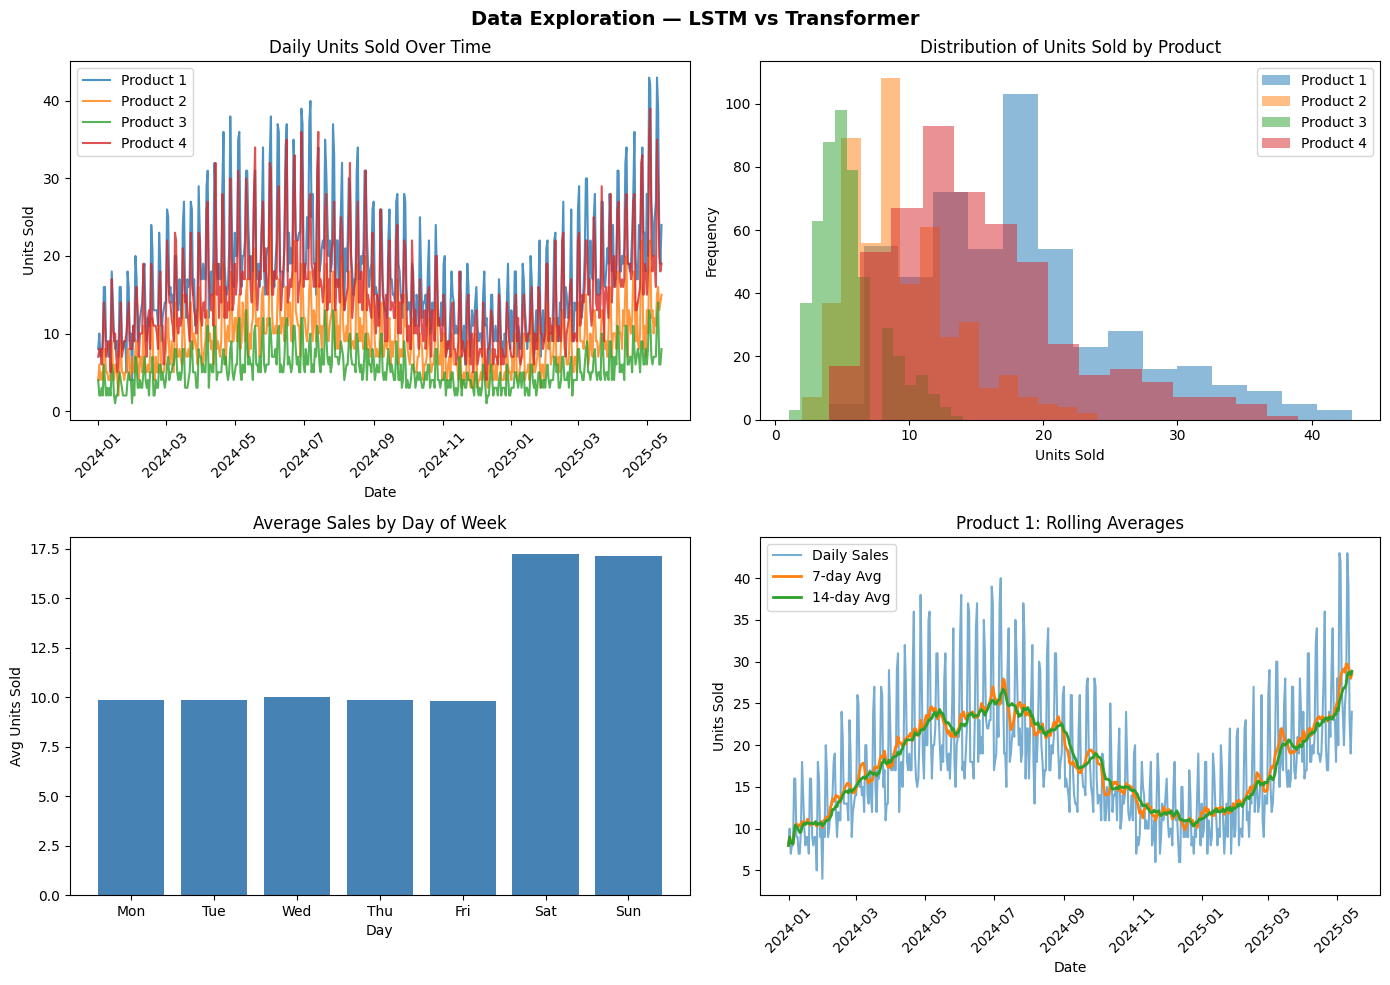

Saved 'data_exploration.png'


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
for pid in df['product_id'].unique():
    pdata = df[df['product_id']==pid]
    ax1.plot(pdata['date'], pdata['units_sold'], label=f'Product {pid}', alpha=0.8)
ax1.set_title('Daily Units Sold Over Time'); ax1.set_xlabel('Date'); ax1.set_ylabel('Units Sold')
ax1.legend(); ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
for pid in df['product_id'].unique():
    ax2.hist(df[df['product_id']==pid]['units_sold'], alpha=0.5, label=f'Product {pid}', bins=15)
ax2.set_title('Distribution of Units Sold by Product')
ax2.set_xlabel('Units Sold'); ax2.set_ylabel('Frequency'); ax2.legend()

ax3 = axes[1, 0]
weekday_avg = df.groupby('weekday')['units_sold'].mean()
ax3.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekday_avg.values, color='steelblue')
ax3.set_title('Average Sales by Day of Week'); ax3.set_xlabel('Day'); ax3.set_ylabel('Avg Units Sold')

ax4 = axes[1, 1]
p1_plot = df[df['product_id']==1].copy()
ax4.plot(p1_plot['date'], p1_plot['units_sold'], label='Daily Sales', alpha=0.6)
ax4.plot(p1_plot['date'], p1_plot['rolling_avg_7'],  label='7-day Avg',  linewidth=2)
ax4.plot(p1_plot['date'], p1_plot['rolling_avg_14'], label='14-day Avg', linewidth=2)
ax4.set_title('Product 1: Rolling Averages')
ax4.set_xlabel('Date'); ax4.set_ylabel('Units Sold')
ax4.legend(); ax4.tick_params(axis='x', rotation=45)

plt.suptitle('Data Exploration — LSTM vs Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 'data_exploration.png'")

## 4. LSTM Model Architecture

**Architecture (identical to v4):**
- 3 stacked LSTM layers: 128 → 64 → 32
- L2 regularisation (1e-4) on all LSTM layers
- Dense head: 64 → 32 → 1
- Loss: **MSE**, Window: **30 days**, Features: **16**

In [5]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        LSTM(64, return_sequences=True,
             kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        LSTM(32, return_sequences=False,
             kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

print('LSTM MODEL ARCHITECTURE')
print('='*60)
_preview_lstm = build_lstm_model(input_shape=(30, 16))
_preview_lstm.summary()

LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,289 (548.00 KB)

 Trainable params: 140,289 (548.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Data Preparation

In [6]:
def create_sequence_dataset(df, feature_cols, target_col, window_size=30, product_id=None):
    data = df[df['product_id']==product_id].copy() if product_id else df.copy()
    data = data.sort_values('date').reset_index(drop=True)
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[feature_cols].iloc[i:i+window_size].values)
        y.append(data[target_col].iloc[i+window_size])
    return np.array(X), np.array(y), data

FEATURE_COLS = [
    'selling_price', 'market_avg_price', 'discount_percent',
    'rolling_avg_7', 'rolling_avg_14', 'rolling_avg_30',
    'is_weekend', 'price_ratio', 'discount_effect',
    'lag_1', 'lag_7', 'demand_trend',
    'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos'
]
TARGET_COL  = 'units_sold'
WINDOW_SIZE = 30

X, y, product_df = create_sequence_dataset(df, FEATURE_COLS, TARGET_COL, WINDOW_SIZE, product_id=1)

print('DATASET PREPARED')
print('='*60)
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Window size     : {WINDOW_SIZE} days')
print(f'X shape         : {X.shape}')
print(f'Target mean/std : {y.mean():.2f} / {y.std():.2f}  (min {y.min()}, max {y.max()})')

DATASET PREPARED
Features (16): ['selling_price', 'market_avg_price', 'discount_percent', 'rolling_avg_7', 'rolling_avg_14', 'rolling_avg_30', 'is_weekend', 'price_ratio', 'discount_effect', 'lag_1', 'lag_7', 'demand_trend', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
Window size     : 30 days
X shape         : (470, 30, 16)
Target mean/std : 18.48 / 7.44  (min 4, max 43)


In [7]:
n_samples, n_timesteps, n_features = X.shape
train_size = int(len(X) * 0.8)

X_train_raw, X_test_raw = X[:train_size], X[train_size:]
y_train_raw, y_test_raw = y[:train_size], y[train_size:]
y_test_original = y[train_size:]

# Scalers fitted on training data only — no leakage
lstm_scaler_X = MinMaxScaler()
lstm_scaler_y = MinMaxScaler()

X_train = lstm_scaler_X.fit_transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_test  = lstm_scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)
y_train = lstm_scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test  = lstm_scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

print('DATA SPLIT — LSTM (no scale leakage)')
print('='*60)
print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Scaler fitted on training data only ✓')

DATA SPLIT — LSTM (no scale leakage)
Training samples : 376
Testing  samples : 94
Scaler fitted on training data only ✓


## 6. LSTM Training

In [8]:
print('TRAINING LSTM MODEL')
print('='*60)

lstm_early_stop = EarlyStopping(monitor='val_loss', patience=25,
                                restore_best_weights=True, verbose=1)
lstm_reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=1)

lstm_model  = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_params = lstm_model.count_params()

# Light augmentation — preserves signal while improving generalisation
X_train_aug = X_train + 0.005 * np.random.randn(*X_train.shape)

lstm_start_time = time.time()
lstm_history = lstm_model.fit(
    X_train_aug, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.15,
    callbacks=[lstm_early_stop, lstm_reduce_lr],
    verbose=1
)
lstm_training_time = time.time() - lstm_start_time
lstm_epochs_run    = len(lstm_history.history['loss'])

print(f'\nLSTM Training Time : {lstm_training_time:.2f} seconds')
print(f'Epochs completed   : {lstm_epochs_run} / 300')

TRAINING LSTM MODEL
Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - loss: 0.1090 - mae: 0.2145 - val_loss: 0.0441 - val_mae: 0.1136 - learning_rate: 0.0010
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0614 - mae: 0.1419 - val_loss: 0.0448 - val_mae: 0.0965 - learning_rate: 0.0010
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0558 - mae: 0.1356 - val_loss: 0.0411 - val_mae: 0.1028 - learning_rate: 0.0010
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0528 - mae: 0.1311 - val_loss: 0.0397 - val_mae: 0.1023 - learning_rate: 0.0010
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0540 - mae: 0.1377 - val_loss: 0.0413 - val_mae: 0.0964 - learning_rate: 0.0010
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0535 - mae: 0.1383 - val_loss: 0.0376 - val_mae: 0.1013 - learning_rate: 0.0010
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0504 - mae: 0.1313 - val_loss: 0.0371 - val_mae: 0.1009 - learni

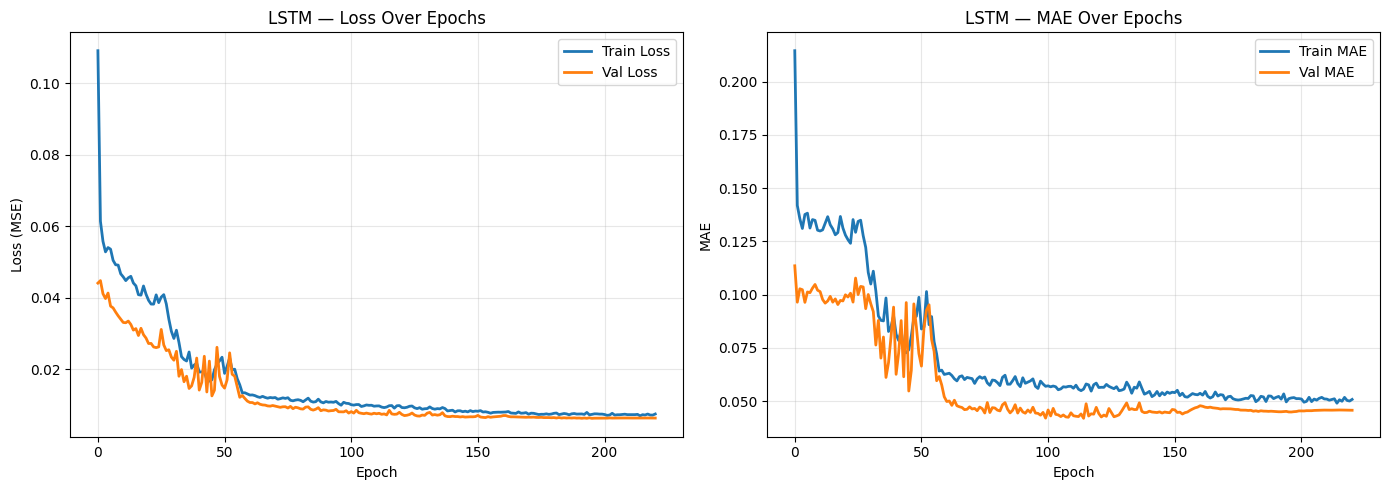

Best val_loss : 0.0062
Best val_mae  : 0.0420


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'],     label='Train Loss',  linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Val Loss',    linewidth=2)
axes[0].set_title('LSTM — Loss Over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_history.history['mae'],     label='Train MAE', linewidth=2)
axes[1].plot(lstm_history.history['val_mae'], label='Val MAE',   linewidth=2)
axes[1].set_title('LSTM — MAE Over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val_loss : {min(lstm_history.history['val_loss']):.4f}")
print(f"Best val_mae  : {min(lstm_history.history['val_mae']):.4f}")

## 7. LSTM Evaluation

In [10]:
y_pred_lstm_scaled   = lstm_model.predict(X_test, verbose=0).flatten()
y_pred_lstm_original = lstm_scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1,1)).flatten()

lstm_mse  = mean_squared_error(y_test_original, y_pred_lstm_original)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae  = mean_absolute_error(y_test_original, y_pred_lstm_original)
lstm_r2   = r2_score(y_test_original, y_pred_lstm_original)
lstm_mape = np.mean(np.abs((y_test_original - y_pred_lstm_original) / y_test_original)) * 100

print('LSTM MODEL EVALUATION RESULTS')
print('='*60)
print(f'MSE        : {lstm_mse:.4f}')
print(f'RMSE       : {lstm_rmse:.4f}')
print(f'MAE        : {lstm_mae:.4f}')
print(f'R2         : {lstm_r2:.4f}')
print(f'MAPE       : {lstm_mape:.2f}%')
print(f'Parameters : {lstm_params:,}')
print(f'Epochs run : {lstm_epochs_run}')
print(f'Train time : {lstm_training_time:.2f}s')
interp = 'Excellent' if lstm_r2 > 0.8 else ('Good' if lstm_r2 > 0.6 else 'Moderate')
print(f'Interpretation: R2={lstm_r2:.3f} → {interp} model fit')

LSTM MODEL EVALUATION RESULTS
MSE        : 20.6482
RMSE       : 4.5440
MAE        : 3.2011
R2         : 0.6272
MAPE       : 14.09%
Parameters : 140,289
Epochs run : 221
Train time : 254.92s
Interpretation: R2=0.627 → Good model fit


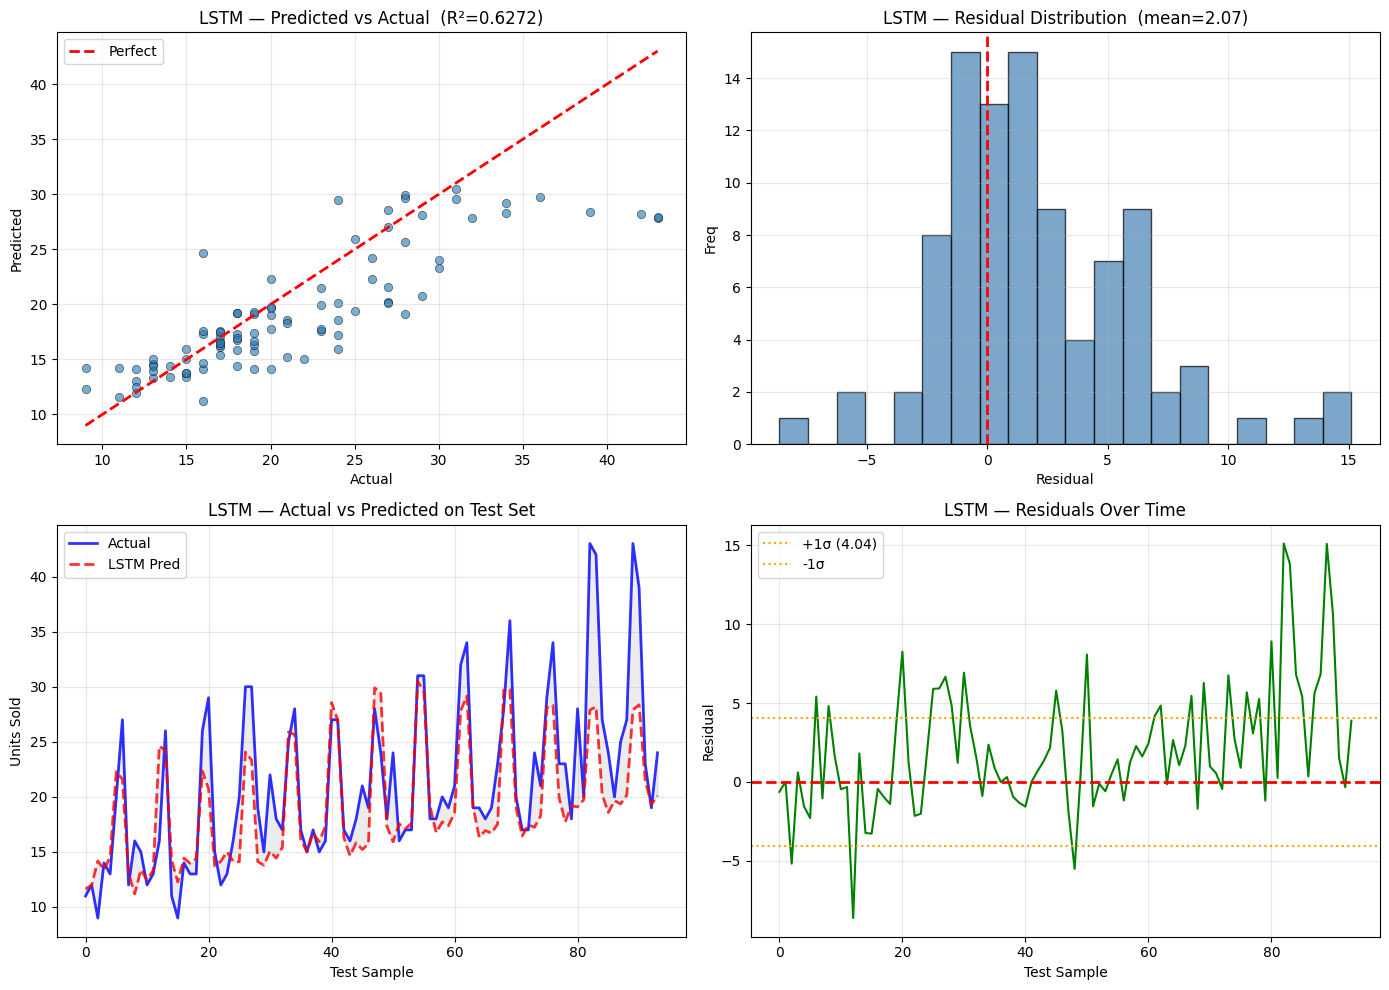

In [11]:
residuals_lstm = y_test_original - y_pred_lstm_original
test_idx       = range(len(y_test_original))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_test_original, y_pred_lstm_original, alpha=0.6, edgecolors='black', lw=0.5)
lims = [y_test_original.min(), y_test_original.max()]
axes[0,0].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title(f'LSTM — Predicted vs Actual  (R²={lstm_r2:.4f})')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(residuals_lstm, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0,1].set_title(f'LSTM — Residual Distribution  (mean={residuals_lstm.mean():.2f})')
axes[0,1].set_xlabel('Residual'); axes[0,1].set_ylabel('Freq'); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(test_idx, y_test_original,    'b-',  label='Actual',    lw=2, alpha=0.8)
axes[1,0].plot(test_idx, y_pred_lstm_original,'r--', label='LSTM Pred', lw=2, alpha=0.8)
axes[1,0].fill_between(test_idx, y_test_original, y_pred_lstm_original, alpha=0.15, color='gray')
axes[1,0].set_xlabel('Test Sample'); axes[1,0].set_ylabel('Units Sold')
axes[1,0].set_title('LSTM — Actual vs Predicted on Test Set')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(test_idx, residuals_lstm, 'g-', lw=1.5)
axes[1,1].axhline(y=0, color='red', linestyle='--', lw=2)
sig = residuals_lstm.std()
axes[1,1].axhline(y= sig, color='orange', linestyle=':', lw=1.5, label=f'+1σ ({sig:.2f})')
axes[1,1].axhline(y=-sig, color='orange', linestyle=':', lw=1.5, label='-1σ')
axes[1,1].set_title('LSTM — Residuals Over Time')
axes[1,1].set_xlabel('Test Sample'); axes[1,1].set_ylabel('Residual')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. LSTM — 7-Day Forecast

In [12]:
def forecast_future(model, last_window_scaled, scaler_X, scaler_y,
                     feature_cols, n_days=7):
    """
    Iterative multi-step forecast.
    Each predicted value is injected back into the sliding window so future
    steps are informed by model predictions rather than stale historical values.
    """
    predictions    = []
    current_window = last_window_scaled.copy()   # shape (1, window, n_features)
    rolling_idx    = feature_cols.index('rolling_avg_7')

    for _ in range(n_days):
        pred_scaled   = model.predict(current_window, verbose=0)[0][0]
        pred_original = scaler_y.inverse_transform([[pred_scaled]])[0][0]
        predictions.append(round(float(pred_original), 2))

        new_step = current_window[0, -1, :].copy()
        new_step[rolling_idx] = pred_scaled   # inject prediction into rolling_avg_7 slot

        current_window = np.concatenate(
            [current_window[:, 1:, :], new_step.reshape(1, 1, -1)], axis=1
        )
    return predictions


lstm_forecasts = forecast_future(
    lstm_model, X_test[-1:].copy(),
    lstm_scaler_X, lstm_scaler_y,
    FEATURE_COLS, n_days=7
)

print('='*60)
print('LSTM — 7-DAY SALES FORECAST')
print('='*60)
for i, f in enumerate(lstm_forecasts, 1):
    print(f'  Day {i}: {f:.0f} units')
print(f'\nTotal 7-day : {sum(lstm_forecasts):.0f} units')
print(f'Daily avg   : {np.mean(lstm_forecasts):.1f} units')

LSTM — 7-DAY SALES FORECAST
  Day 1: 20 units
  Day 2: 20 units
  Day 3: 21 units
  Day 4: 28 units
  Day 5: 28 units
  Day 6: 22 units
  Day 7: 19 units

Total 7-day : 158 units
Daily avg   : 22.6 units


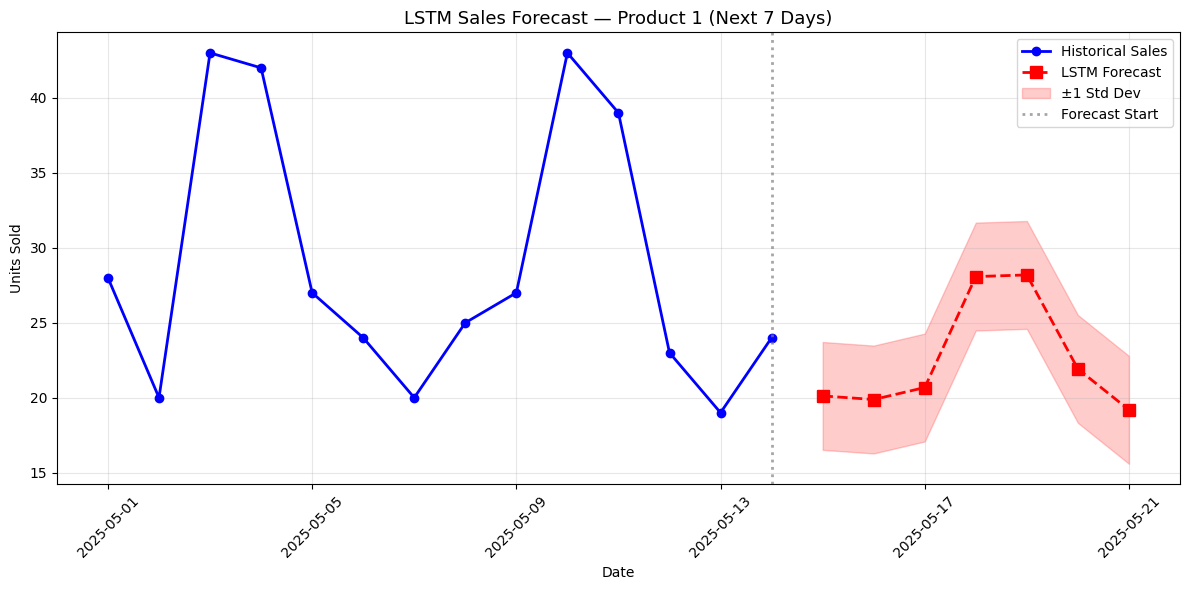

In [13]:
hist_days    = 14
recent_sales = product_df['units_sold'].iloc[-hist_days:].values
recent_dates = pd.date_range(end=product_df['date'].max(), periods=hist_days)
future_dates = pd.date_range(start=product_df['date'].max()+pd.Timedelta(days=1), periods=7)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(recent_dates, recent_sales, 'b-o', lw=2, label='Historical Sales', ms=6)
ax.plot(future_dates, lstm_forecasts, 'r--s', lw=2, label='LSTM Forecast', ms=8)
fstd = np.std(lstm_forecasts)
ax.fill_between(future_dates, [f-fstd for f in lstm_forecasts],
                              [f+fstd for f in lstm_forecasts],
                              alpha=0.2, color='red', label='±1 Std Dev')
ax.axvline(x=product_df['date'].max(), color='gray', linestyle=':', lw=2, alpha=0.7,
           label='Forecast Start')
ax.set_title('LSTM Sales Forecast — Product 1 (Next 7 Days)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Units Sold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. LSTM — Cross-Product Training

In [14]:
lstm_results = []

for pid in df['product_id'].unique():
    print(f"\n{'='*60}")
    print(f'Training LSTM for Product {pid}')
    print('='*60)

    Xp, yp, _ = create_sequence_dataset(df, FEATURE_COLS, TARGET_COL, WINDOW_SIZE, pid)
    ns, nt, nf = Xp.shape
    tr = int(ns * 0.8)
    sX = MinMaxScaler(); sy = MinMaxScaler()
    Xtr = sX.fit_transform(Xp[:tr].reshape(-1,nf)).reshape(Xp[:tr].shape)
    Xte = sX.transform(Xp[tr:].reshape(-1,nf)).reshape(Xp[tr:].shape)
    ytr = sy.fit_transform(yp[:tr].reshape(-1,1)).flatten()
    yte_orig = yp[tr:]

    m = build_lstm_model((nt, nf))
    Xtr_aug = Xtr + 0.005 * np.random.randn(*Xtr.shape)
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0)
    t0 = time.time()
    hist = m.fit(Xtr_aug, ytr, epochs=300, batch_size=32,
                 validation_split=0.15, callbacks=[es, rl], verbose=0)
    tt = time.time() - t0

    yp_sc  = m.predict(Xte, verbose=0).flatten()
    yp_ori = sy.inverse_transform(yp_sc.reshape(-1,1)).flatten()
    r2     = r2_score(yte_orig, yp_ori)
    rmse   = np.sqrt(mean_squared_error(yte_orig, yp_ori))
    mae    = mean_absolute_error(yte_orig, yp_ori)
    mape   = np.mean(np.abs((yte_orig - yp_ori) / yte_orig)) * 100

    lstm_results.append({'Product': pid, 'RMSE': rmse, 'MAE': mae,
                         'R2': r2, 'MAPE': mape, 'Time': tt,
                         'Epochs': len(hist.history['loss'])})
    print(f'RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f} | MAPE={mape:.1f}% | {tt:.1f}s')

lstm_results_df = pd.DataFrame(lstm_results)
print('\nLSTM — CROSS-PRODUCT SUMMARY')
print('='*60)
print(lstm_results_df.to_string(index=False))


Training LSTM for Product 1
RMSE=3.850 | MAE=2.845 | R2=0.732 | MAPE=12.9% | 187.8s

Training LSTM for Product 2


RMSE=2.086 | MAE=1.632 | R2=0.705 | MAPE=16.0% | 101.2s

Training LSTM for Product 3


RMSE=1.293 | MAE=0.984 | R2=0.708 | MAPE=15.3% | 115.8s

Training LSTM for Product 4
RMSE=3.492 | MAE=2.688 | R2=0.722 | MAPE=15.3% | 161.3s

LSTM — CROSS-PRODUCT SUMMARY
 Product     RMSE      MAE       R2      MAPE       Time  Epochs
       1 3.849866 2.845206 0.732426 12.885901 187.807638     193
       2 2.086107 1.632033 0.704556 15.975193 101.233248     104
       3 1.292566 0.984011 0.708435 15.297316 115.811950     114
       4 3.491848 2.687759 0.722307 15.267496 161.266358     172


---
# ═══════════════════════════════════════
# PART 2 — LIGHTWEIGHT TRANSFORMER MODEL
# ═══════════════════════════════════════

## Why Positional Encoding?

Unlike LSTMs, the Transformer's **self-attention mechanism is permutation-invariant** — it treats the input as a *set* of tokens, not a *sequence*. This means without positional encoding, the model cannot distinguish Day 1 from Day 30 in the window.

**Sinusoidal Positional Encoding** (Vaswani et al. 2017, "Attention Is All You Need") fixes this by adding unique sine/cosine signals to each position:

```
PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
```

- `pos` = timestep index (0 … window_size-1)
- `i`   = feature dimension index
- Each dimension gets a wave of a different frequency
- No learned parameters — deterministic, generalises to unseen lengths

For time-series forecasting this is critical: the model must know *how far back* each observation sits relative to the forecast point.

## 10. Transformer Architecture with Positional Encoding

In [15]:
class SinusoidalPositionalEncoding(Layer):
    """
    Adds fixed sinusoidal positional encoding to the input tensor.

    Reference: Vaswani et al. (2017), 'Attention Is All You Need'.

    Formula:
        PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

    Why this works for demand forecasting:
        - Transformers are permutation-invariant by design; without PE,
          Day 1 and Day 30 look identical to the attention heads.
        - Sinusoidal PE gives each position a unique fingerprint across
          all feature dimensions, letting attention heads learn *when*
          each observation occurred relative to the forecast horizon.
        - Different frequencies encode different temporal scales:
          low-frequency dimensions capture long-range position (e.g. week
          vs month), high-frequency dimensions capture fine-grained order.
        - No learned parameters → robust to short datasets.
    """

    def __init__(self, max_len=500, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]          # dynamic sequence length
        d_model = inputs.shape[-1]             # feature dimension (static)

        # Build PE matrix of shape (seq_len, d_model)
        positions = tf.cast(tf.range(seq_len)[:, tf.newaxis], dtype=tf.float32)  # (seq, 1)
        i         = tf.cast(tf.range(d_model)[tf.newaxis, :], dtype=tf.float32)  # (1, d_model)

        # Angle: pos / 10000^(2i / d_model)
        angle_rates = 1.0 / tf.pow(
            10000.0, (2.0 * tf.math.floor(i / 2.0)) / tf.cast(d_model, tf.float32)
        )
        angles = positions * angle_rates   # (seq, d_model)

        # Apply sin to even indices, cos to odd indices
        sin_enc = tf.math.sin(angles[:, 0::2])  # even columns
        cos_enc = tf.math.cos(angles[:, 1::2])  # odd columns

        # Interleave sin and cos back to full d_model width
        pe = tf.reshape(
            tf.stack([sin_enc, cos_enc], axis=-1),
            [seq_len, -1]
        )[:, :d_model]   # trim if d_model is odd

        # Broadcast across batch: (1, seq, d_model) + (batch, seq, d_model)
        pe = tf.cast(pe[tf.newaxis, :, :], dtype=inputs.dtype)
        return inputs + pe

    def get_config(self):
        config = super().get_config()
        config.update({'max_len': self.max_len})
        return config


def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    """
    Single Transformer encoder block:
      1. Multi-Head Self-Attention  (captures which timesteps attend to which)
      2. Residual connection + LayerNorm
      3. Position-wise Feed-Forward (2 Dense layers with ReLU)
      4. Residual connection + LayerNorm

    Kept lightweight: head_size=32, num_heads=2, ff_dim=64.
    Heavy configs overfit on short tabular sequences.
    """
    # --- Self-Attention ---
    attn_out = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)
    attn_out  = Dropout(dropout)(attn_out)
    attn_norm = LayerNormalization(epsilon=1e-6)(inputs + attn_out)  # residual

    # --- Feed-Forward ---
    ff = Dense(ff_dim, activation='relu')(attn_norm)
    ff = Dropout(dropout)(ff)
    ff = Dense(inputs.shape[-1])(ff)       # project back to model dim
    ff_norm = LayerNormalization(epsilon=1e-6)(attn_norm + ff)       # residual

    return ff_norm


def build_light_transformer(input_shape,
                             head_size=32, num_heads=2,
                             ff_dim=64, dropout=0.1,
                             dense_dim=32, dense_dropout=0.2):
    """
    Full lightweight transformer for univariate/multivariate time-series regression.

    Architecture:
        Input (batch, timesteps, features)
          → SinusoidalPositionalEncoding      # inject temporal order
          → TransformerEncoderBlock × 2       # attend + FFN
          → GlobalAveragePooling1D            # collapse time axis
          → Dense(32, relu)
          → Dropout(0.2)
          → Dense(1)                          # regression output
    """
    inputs = Input(shape=input_shape)

    # Step 1: Positional encoding — tells attention heads the timestep order
    x = SinusoidalPositionalEncoding()(inputs)

    # Step 2: Two lightweight encoder blocks
    x = transformer_encoder_block(x, head_size=head_size, num_heads=num_heads,
                                   ff_dim=ff_dim, dropout=dropout)
    x = transformer_encoder_block(x, head_size=head_size, num_heads=num_heads,
                                   ff_dim=ff_dim, dropout=dropout)

    # Step 3: Aggregate across the time dimension
    x = GlobalAveragePooling1D()(x)

    # Step 4: Classification/regression head
    x = Dense(dense_dim, activation='relu')(x)
    x = Dropout(dense_dropout)(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


print('LIGHTWEIGHT TRANSFORMER ARCHITECTURE')
print('='*60)
print('Components:')
print('  • SinusoidalPositionalEncoding  — no learnable params')
print('  • TransformerEncoderBlock × 2   — head_size=32, num_heads=2, ff_dim=64')
print('  • GlobalAveragePooling1D')
print('  • Dense(32, relu) → Dropout(0.2) → Dense(1)')
print()
_preview_tfm = build_light_transformer(input_shape=(30, 16))
_preview_tfm.summary()

LIGHTWEIGHT TRANSFORMER ARCHITECTURE
Components:
  • SinusoidalPositionalEncoding  — no learnable params
  • TransformerEncoderBlock × 2   — head_size=32, num_heads=2, ff_dim=64
  • GlobalAveragePooling1D
  • Dense(32, relu) → Dropout(0.2) → Dense(1)



Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 30, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinusoidal_positio… │ (None, 30, 16)    │          0 │ input_layer_6[0]… │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 16)    │      4,304 │ sinusoidal_posit… │
│ (MultiHeadAttentio… │                   │            │ sinusoidal_posit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 30, 16)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 16)    │          0 │ sinusoidal_posit… │
│                     │                   │            │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 16)    │         32 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 30, 64)    │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 30, 64)    │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 30, 16)    │      1,040 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 16)    │         32 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 16)    │      4,304 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 30, 16)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 16)    │         32 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 30, 64)    │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 30, 64)    │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 30, 16)    │      1,040 │ dropout_23[0][0]

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Transformer Data Preparation

Same dataset, same features, same window — separate scalers to keep the comparison clean.

In [16]:
# Re-use the same raw X, y from Part 1 (Product 1)
Xt, yt, product_df_tfm = create_sequence_dataset(
    df, FEATURE_COLS, TARGET_COL, WINDOW_SIZE, product_id=1
)

nt_s, nt_t, nt_f = Xt.shape
tr_t = int(nt_s * 0.8)

Xt_train_raw, Xt_test_raw = Xt[:tr_t], Xt[tr_t:]
yt_train_raw, yt_test_raw = yt[:tr_t], yt[tr_t:]
yt_test_original = yt[tr_t:]

# Independent scalers — fit on training only
tfm_scaler_X = MinMaxScaler()
tfm_scaler_y = MinMaxScaler()

Xt_train = tfm_scaler_X.fit_transform(Xt_train_raw.reshape(-1, nt_f)).reshape(Xt_train_raw.shape)
Xt_test  = tfm_scaler_X.transform(Xt_test_raw.reshape(-1, nt_f)).reshape(Xt_test_raw.shape)
yt_train = tfm_scaler_y.fit_transform(yt_train_raw.reshape(-1, 1)).flatten()
yt_test  = tfm_scaler_y.transform(yt_test_raw.reshape(-1, 1)).flatten()

print('DATA SPLIT — TRANSFORMER (no scale leakage)')
print('='*60)
print(f'Training samples : {len(Xt_train)}')
print(f'Testing  samples : {len(Xt_test)}')

DATA SPLIT — TRANSFORMER (no scale leakage)
Training samples : 376
Testing  samples : 94


## 12. Transformer Training

In [17]:
print('TRAINING LIGHTWEIGHT TRANSFORMER')
print('='*60)

tfm_early_stop = EarlyStopping(monitor='val_loss', patience=25,
                                restore_best_weights=True, verbose=1)
tfm_reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=1)

tfm_model  = build_light_transformer(input_shape=(Xt_train.shape[1], Xt_train.shape[2]))
tfm_params = tfm_model.count_params()

# Same light augmentation as LSTM
Xt_train_aug = Xt_train + 0.005 * np.random.randn(*Xt_train.shape)

tfm_start_time = time.time()
tfm_history = tfm_model.fit(
    Xt_train_aug, yt_train,
    epochs=300,
    batch_size=32,
    validation_split=0.15,
    callbacks=[tfm_early_stop, tfm_reduce_lr],
    verbose=1
)
tfm_training_time = time.time() - tfm_start_time
tfm_epochs_run    = len(tfm_history.history['loss'])

print(f'\nTransformer Training Time : {tfm_training_time:.2f} seconds')
print(f'Epochs completed          : {tfm_epochs_run} / 300')

TRAINING LIGHTWEIGHT TRANSFORMER
Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.1970 - mae: 0.3407 - val_loss: 0.0244 - val_mae: 0.1086 - learning_rate: 0.0010
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0848 - mae: 0.2334 - val_loss: 0.0304 - val_mae: 0.1567 - learning_rate: 0.0010
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0526 - mae: 0.1786 - val_loss: 0.0146 - val_mae: 0.1050 - learning_rate: 0.0010
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0476 - mae: 0.1791 - val_loss: 0.0139 - val_mae: 0.0973 - learning_rate: 0.0010
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0410 - mae: 0.1620 - val_loss: 0.0135 - val_mae: 0.0959 - learning_rate: 0.0010
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0468 - mae: 0.1718 - val_loss: 0.0134 - val_mae: 0.0951 - learning_rate: 0.0010
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0386 - mae: 0.1554 - val_loss: 0.0135 - val_mae: 0.09

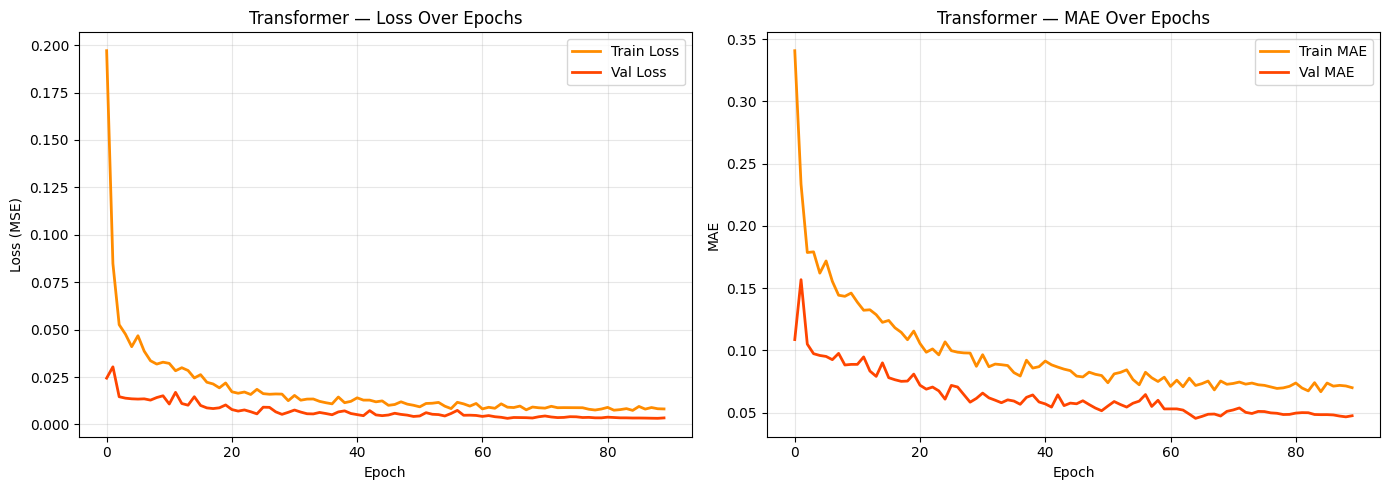

Best val_loss : 0.0032
Best val_mae  : 0.0454


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tfm_history.history['loss'],     label='Train Loss', linewidth=2, color='darkorange')
axes[0].plot(tfm_history.history['val_loss'], label='Val Loss',   linewidth=2, color='orangered')
axes[0].set_title('Transformer — Loss Over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(tfm_history.history['mae'],     label='Train MAE', linewidth=2, color='darkorange')
axes[1].plot(tfm_history.history['val_mae'], label='Val MAE',   linewidth=2, color='orangered')
axes[1].set_title('Transformer — MAE Over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val_loss : {min(tfm_history.history['val_loss']):.4f}")
print(f"Best val_mae  : {min(tfm_history.history['val_mae']):.4f}")

## 13. Transformer Evaluation

In [19]:
y_pred_tfm_scaled   = tfm_model.predict(Xt_test, verbose=0).flatten()
y_pred_tfm_original = tfm_scaler_y.inverse_transform(y_pred_tfm_scaled.reshape(-1,1)).flatten()

tfm_mse  = mean_squared_error(yt_test_original, y_pred_tfm_original)
tfm_rmse = np.sqrt(tfm_mse)
tfm_mae  = mean_absolute_error(yt_test_original, y_pred_tfm_original)
tfm_r2   = r2_score(yt_test_original, y_pred_tfm_original)
tfm_mape = np.mean(np.abs((yt_test_original - y_pred_tfm_original) / yt_test_original)) * 100

print('TRANSFORMER MODEL EVALUATION RESULTS')
print('='*60)
print(f'MSE        : {tfm_mse:.4f}')
print(f'RMSE       : {tfm_rmse:.4f}')
print(f'MAE        : {tfm_mae:.4f}')
print(f'R2         : {tfm_r2:.4f}')
print(f'MAPE       : {tfm_mape:.2f}%')
print(f'Parameters : {tfm_params:,}')
print(f'Epochs run : {tfm_epochs_run}')
print(f'Train time : {tfm_training_time:.2f}s')
interp = 'Excellent' if tfm_r2 > 0.8 else ('Good' if tfm_r2 > 0.6 else 'Moderate')
print(f'Interpretation: R2={tfm_r2:.3f} → {interp} model fit')

TRANSFORMER MODEL EVALUATION RESULTS
MSE        : 11.8146
RMSE       : 3.4372
MAE        : 2.4902
R2         : 0.7867
MAPE       : 11.37%
Parameters : 13,569
Epochs run : 90
Train time : 47.46s
Interpretation: R2=0.787 → Good model fit


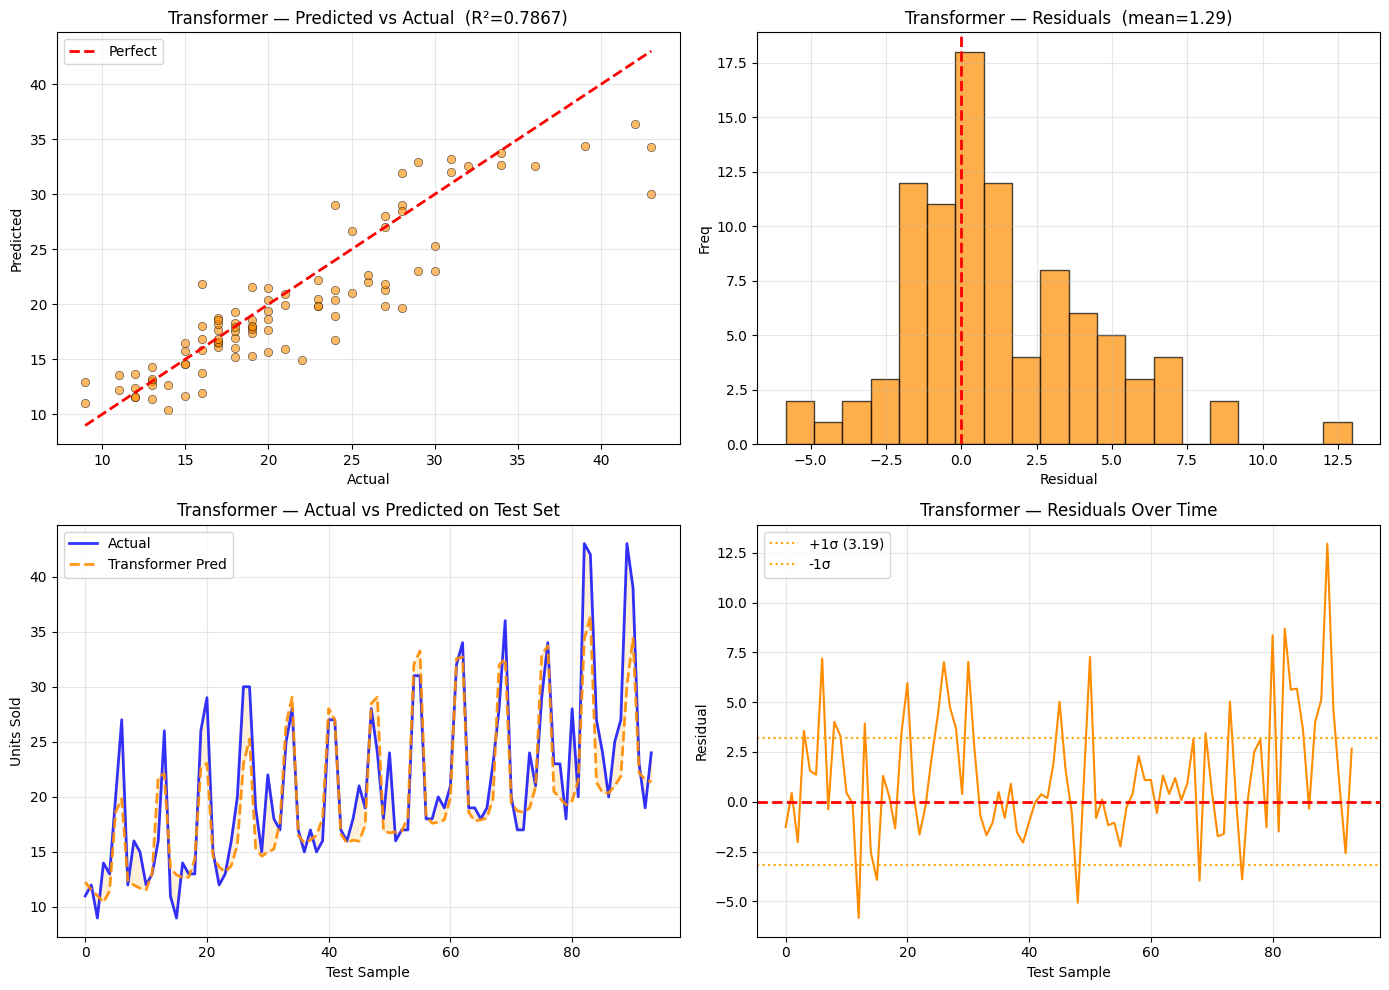

In [20]:
residuals_tfm = yt_test_original - y_pred_tfm_original
tidx = range(len(yt_test_original))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(yt_test_original, y_pred_tfm_original, alpha=0.6,
                  edgecolors='black', lw=0.5, color='darkorange')
lims = [yt_test_original.min(), yt_test_original.max()]
axes[0,0].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[0,0].set_title(f'Transformer — Predicted vs Actual  (R²={tfm_r2:.4f})')
axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(residuals_tfm, bins=20, edgecolor='black', alpha=0.7, color='darkorange')
axes[0,1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0,1].set_title(f'Transformer — Residuals  (mean={residuals_tfm.mean():.2f})')
axes[0,1].set_xlabel('Residual'); axes[0,1].set_ylabel('Freq'); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(tidx, yt_test_original,    'b-',  label='Actual',          lw=2, alpha=0.8)
axes[1,0].plot(tidx, y_pred_tfm_original, '--',  label='Transformer Pred', lw=2,
               alpha=0.9, color='darkorange')
axes[1,0].fill_between(tidx, yt_test_original, y_pred_tfm_original, alpha=0.15, color='orange')
axes[1,0].set_title('Transformer — Actual vs Predicted on Test Set')
axes[1,0].set_xlabel('Test Sample'); axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(tidx, residuals_tfm, color='darkorange', lw=1.5)
axes[1,1].axhline(y=0, color='red', linestyle='--', lw=2)
sig_t = residuals_tfm.std()
axes[1,1].axhline(y= sig_t, color='orange', linestyle=':', lw=1.5, label=f'+1σ ({sig_t:.2f})')
axes[1,1].axhline(y=-sig_t, color='orange', linestyle=':', lw=1.5, label='-1σ')
axes[1,1].set_title('Transformer — Residuals Over Time')
axes[1,1].set_xlabel('Test Sample'); axes[1,1].set_ylabel('Residual')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Transformer — 7-Day Forecast

TRANSFORMER — 7-DAY SALES FORECAST
  Day 1: 21 units
  Day 2: 21 units
  Day 3: 22 units
  Day 4: 31 units
  Day 5: 31 units
  Day 6: 22 units
  Day 7: 20 units

Total 7-day : 169 units
Daily avg   : 24.2 units


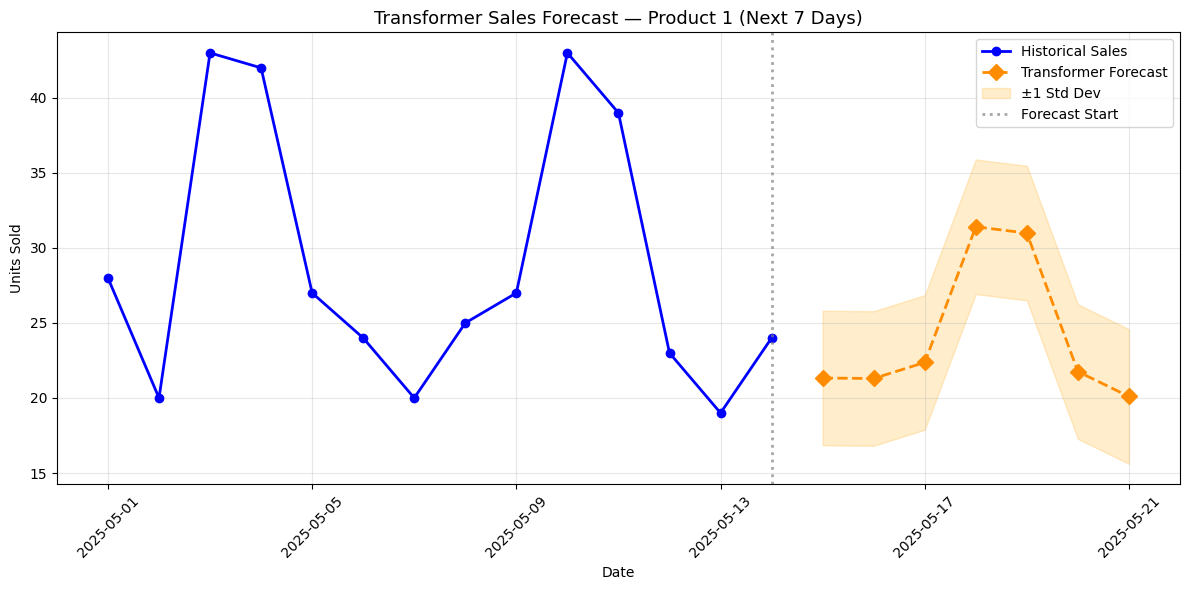

In [21]:
tfm_forecasts = forecast_future(
    tfm_model, Xt_test[-1:].copy(),
    tfm_scaler_X, tfm_scaler_y,
    FEATURE_COLS, n_days=7
)

print('='*60)
print('TRANSFORMER — 7-DAY SALES FORECAST')
print('='*60)
for i, f in enumerate(tfm_forecasts, 1):
    print(f'  Day {i}: {f:.0f} units')
print(f'\nTotal 7-day : {sum(tfm_forecasts):.0f} units')
print(f'Daily avg   : {np.mean(tfm_forecasts):.1f} units')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(recent_dates, recent_sales, 'b-o', lw=2, label='Historical Sales', ms=6)
ax.plot(future_dates, tfm_forecasts, '--D', lw=2,
        label='Transformer Forecast', ms=8, color='darkorange')
tfstd = np.std(tfm_forecasts)
ax.fill_between(future_dates,
                [f-tfstd for f in tfm_forecasts],
                [f+tfstd for f in tfm_forecasts],
                alpha=0.2, color='orange', label='±1 Std Dev')
ax.axvline(x=product_df['date'].max(), color='gray', linestyle=':', lw=2,
           alpha=0.7, label='Forecast Start')
ax.set_title('Transformer Sales Forecast — Product 1 (Next 7 Days)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Units Sold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('transformer_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Transformer — Cross-Product Training

In [22]:
tfm_results = []

for pid in df['product_id'].unique():
    print(f"\n{'='*60}")
    print(f'Training Transformer for Product {pid}')
    print('='*60)

    Xp, yp, _ = create_sequence_dataset(df, FEATURE_COLS, TARGET_COL, WINDOW_SIZE, pid)
    ns, nt, nf = Xp.shape
    tr = int(ns * 0.8)
    sX = MinMaxScaler(); sy = MinMaxScaler()
    Xtr = sX.fit_transform(Xp[:tr].reshape(-1,nf)).reshape(Xp[:tr].shape)
    Xte = sX.transform(Xp[tr:].reshape(-1,nf)).reshape(Xp[tr:].shape)
    ytr = sy.fit_transform(yp[:tr].reshape(-1,1)).flatten()
    yte_orig = yp[tr:]

    m = build_light_transformer((nt, nf))
    Xtr_aug = Xtr + 0.005 * np.random.randn(*Xtr.shape)
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0)
    t0 = time.time()
    hist = m.fit(Xtr_aug, ytr, epochs=300, batch_size=32,
                 validation_split=0.15, callbacks=[es, rl], verbose=0)
    tt = time.time() - t0

    yp_sc  = m.predict(Xte, verbose=0).flatten()
    yp_ori = sy.inverse_transform(yp_sc.reshape(-1,1)).flatten()
    r2     = r2_score(yte_orig, yp_ori)
    rmse   = np.sqrt(mean_squared_error(yte_orig, yp_ori))
    mae    = mean_absolute_error(yte_orig, yp_ori)
    mape   = np.mean(np.abs((yte_orig - yp_ori) / yte_orig)) * 100

    tfm_results.append({'Product': pid, 'RMSE': rmse, 'MAE': mae,
                        'R2': r2, 'MAPE': mape, 'Time': tt,
                        'Epochs': len(hist.history['loss'])})
    print(f'RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f} | MAPE={mape:.1f}% | {tt:.1f}s')

tfm_results_df = pd.DataFrame(tfm_results)
print('\nTRANSFORMER — CROSS-PRODUCT SUMMARY')
print('='*60)
print(tfm_results_df.to_string(index=False))


Training Transformer for Product 1
RMSE=3.976 | MAE=2.974 | R2=0.715 | MAPE=13.6% | 37.3s

Training Transformer for Product 2
RMSE=2.193 | MAE=1.769 | R2=0.674 | MAPE=16.1% | 35.6s

Training Transformer for Product 3
RMSE=1.168 | MAE=0.938 | R2=0.762 | MAPE=16.2% | 52.7s

Training Transformer for Product 4
RMSE=2.750 | MAE=2.222 | R2=0.828 | MAPE=12.9% | 35.1s

TRANSFORMER — CROSS-PRODUCT SUMMARY
 Product     RMSE      MAE       R2      MAPE      Time  Epochs
       1 3.976013 2.973705 0.714604 13.639146 37.299700      71
       2 2.192809 1.768921 0.673560 16.143579 35.620485      68
       3 1.168500 0.937950 0.761720 16.241823 52.748655     107
       4 2.750169 2.221940 0.827745 12.945742 35.077404      66


---
# ═══════════════════════════════════════
# PART 3 — HEAD-TO-HEAD COMPARISON
# ═══════════════════════════════════════

## 16. Metric Comparison Table

In [23]:
def best_label(vals, higher=False):
    labels = ['LSTM', 'Transformer']
    idx = np.argmax(vals) if higher else np.argmin(vals)
    return labels[idx] + ' ✓'

all_rmse   = [lstm_rmse,          tfm_rmse]
all_mae    = [lstm_mae,           tfm_mae]
all_r2     = [lstm_r2,            tfm_r2]
all_mape   = [lstm_mape,          tfm_mape]
all_time   = [lstm_training_time, tfm_training_time]
all_params = [lstm_params,        tfm_params]

comparison_df = pd.DataFrame({
    'Metric'     : ['RMSE', 'MAE', 'R²', 'MAPE (%)', 'Training Time (s)', 'Parameters'],
    'LSTM'       : [
        f'{lstm_rmse:.4f}', f'{lstm_mae:.4f}', f'{lstm_r2:.4f}',
        f'{lstm_mape:.2f}', f'{lstm_training_time:.1f}', f'{lstm_params:,}'
    ],
    'Transformer': [
        f'{tfm_rmse:.4f}', f'{tfm_mae:.4f}', f'{tfm_r2:.4f}',
        f'{tfm_mape:.2f}', f'{tfm_training_time:.1f}', f'{tfm_params:,}'
    ],
    'Best'       : [
        best_label(all_rmse),
        best_label(all_mae),
        best_label(all_r2, higher=True),
        best_label(all_mape),
        best_label(all_time),
        best_label(all_params)
    ]
})

print('='*75)
print('LSTM vs LIGHTWEIGHT TRANSFORMER — HEAD-TO-HEAD (Product 1, window=30)')
print('='*75)
print(comparison_df.to_string(index=False))

LSTM vs LIGHTWEIGHT TRANSFORMER — HEAD-TO-HEAD (Product 1, window=30)
           Metric    LSTM Transformer          Best
             RMSE  4.5440      3.4372 Transformer ✓
              MAE  3.2011      2.4902 Transformer ✓
               R²  0.6272      0.7867 Transformer ✓
         MAPE (%)   14.09       11.37 Transformer ✓
Training Time (s)   254.9        47.5 Transformer ✓
       Parameters 140,289      13,569 Transformer ✓


## 17. Visual Comparison

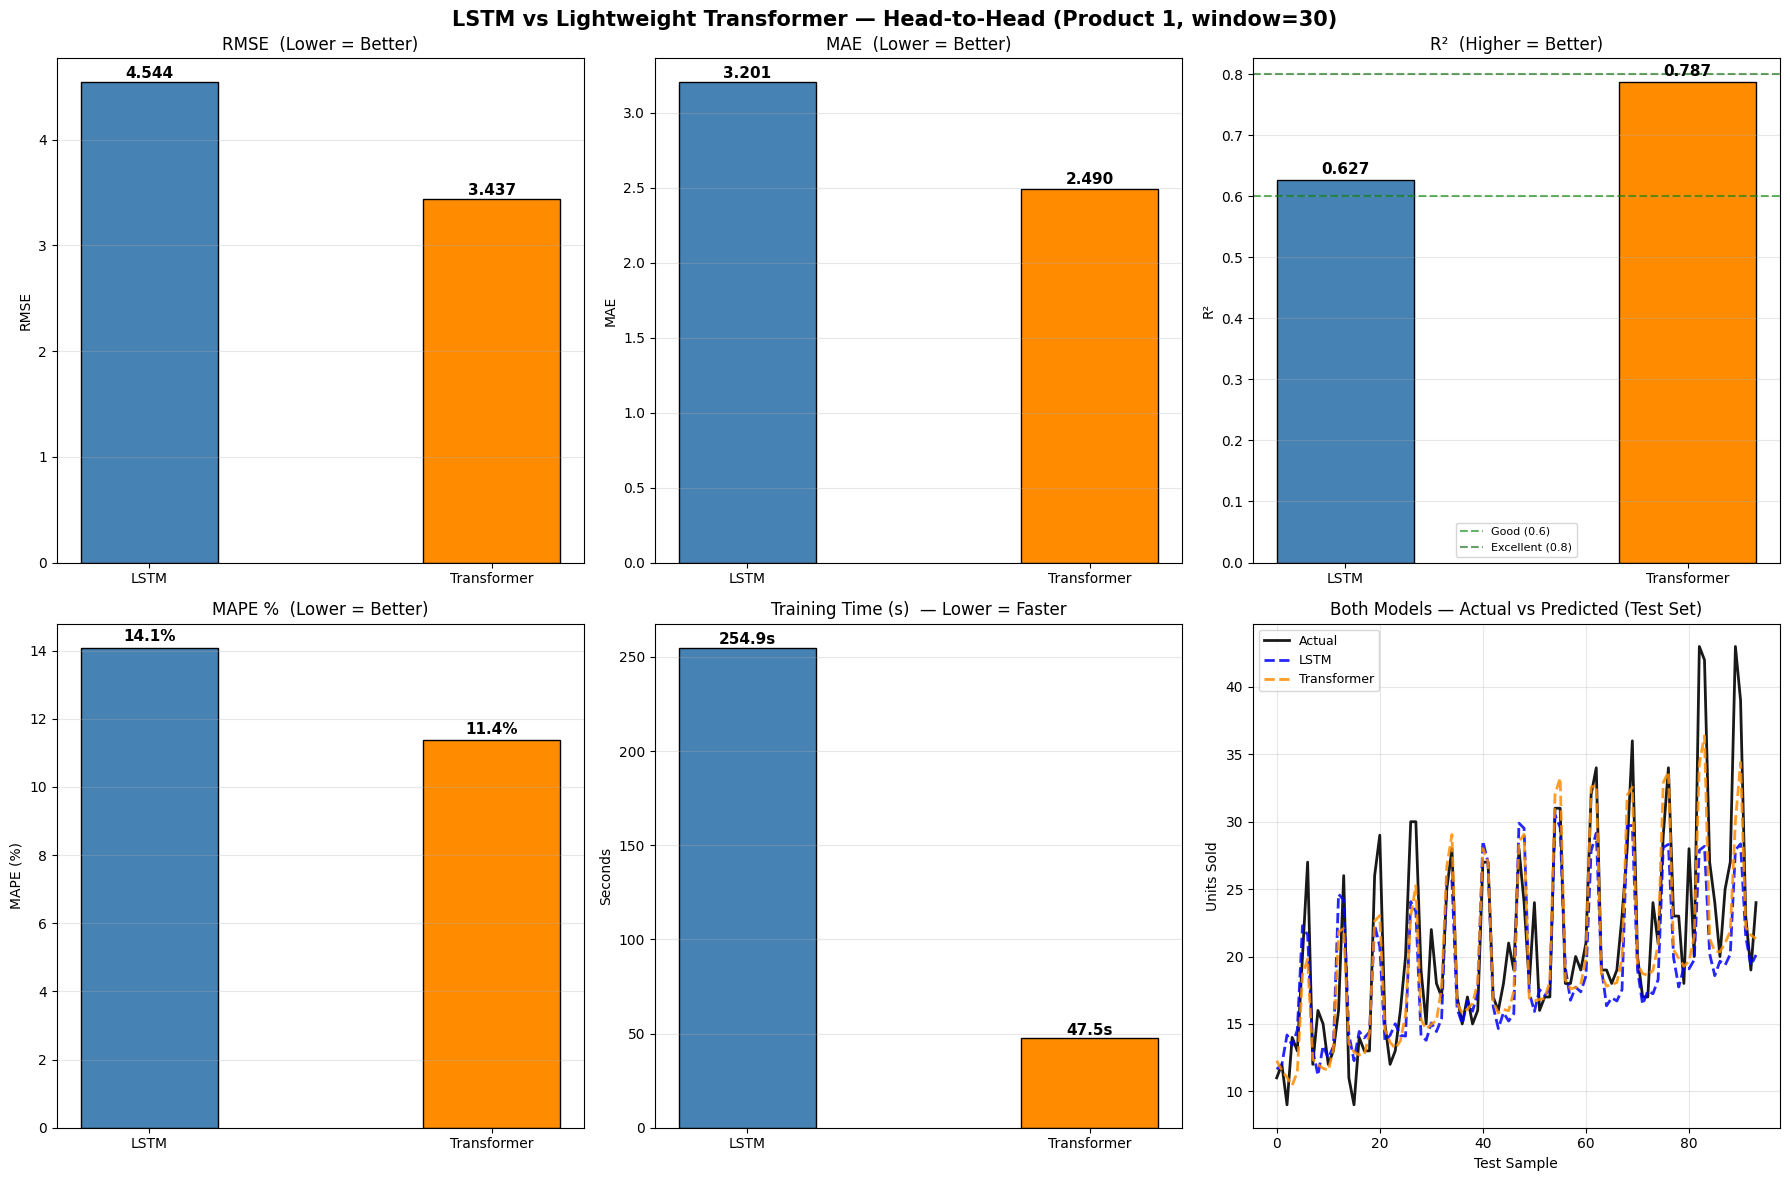

Saved 'lstm_vs_transformer_comparison.png'


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

model_names = ['LSTM', 'Transformer']
colors2     = ['steelblue', 'darkorange']

# RMSE
bars = axes[0,0].bar(model_names, all_rmse, color=colors2, edgecolor='black', width=0.4)
axes[0,0].set_title('RMSE  (Lower = Better)')
axes[0,0].set_ylabel('RMSE'); axes[0,0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, all_rmse):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MAE
bars = axes[0,1].bar(model_names, all_mae, color=colors2, edgecolor='black', width=0.4)
axes[0,1].set_title('MAE  (Lower = Better)')
axes[0,1].set_ylabel('MAE'); axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, all_mae):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# R2
bars = axes[0,2].bar(model_names, all_r2, color=colors2, edgecolor='black', width=0.4)
axes[0,2].axhline(y=0.6, color='green',     linestyle='--', alpha=0.6, label='Good (0.6)')
axes[0,2].axhline(y=0.8, color='darkgreen', linestyle='--', alpha=0.6, label='Excellent (0.8)')
axes[0,2].set_title('R²  (Higher = Better)')
axes[0,2].set_ylabel('R²'); axes[0,2].legend(fontsize=8)
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, all_r2):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MAPE
bars = axes[1,0].bar(model_names, all_mape, color=colors2, edgecolor='black', width=0.4)
axes[1,0].set_title('MAPE %  (Lower = Better)')
axes[1,0].set_ylabel('MAPE (%)'); axes[1,0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, all_mape):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Training time
bars = axes[1,1].bar(model_names, all_time, color=colors2, edgecolor='black', width=0.4)
axes[1,1].set_title('Training Time (s)  — Lower = Faster')
axes[1,1].set_ylabel('Seconds'); axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, all_time):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{v:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Actual vs all preds on test set
common = min(len(y_test_original), len(yt_test_original))
tidx2  = range(common)
axes[1,2].plot(tidx2, y_test_original[:common],       'k-',  label='Actual',      lw=2, alpha=0.9)
axes[1,2].plot(tidx2, y_pred_lstm_original[:common],  'b--', label='LSTM',        lw=2, alpha=0.85)
axes[1,2].plot(tidx2, y_pred_tfm_original[:common],   '--',  label='Transformer', lw=2,
               alpha=0.85, color='darkorange')
axes[1,2].set_title('Both Models — Actual vs Predicted (Test Set)')
axes[1,2].set_xlabel('Test Sample'); axes[1,2].set_ylabel('Units Sold')
axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)

plt.suptitle('LSTM vs Lightweight Transformer — Head-to-Head (Product 1, window=30)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_vs_transformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 'lstm_vs_transformer_comparison.png'")

## 18. Forecast Overlay — Both Models

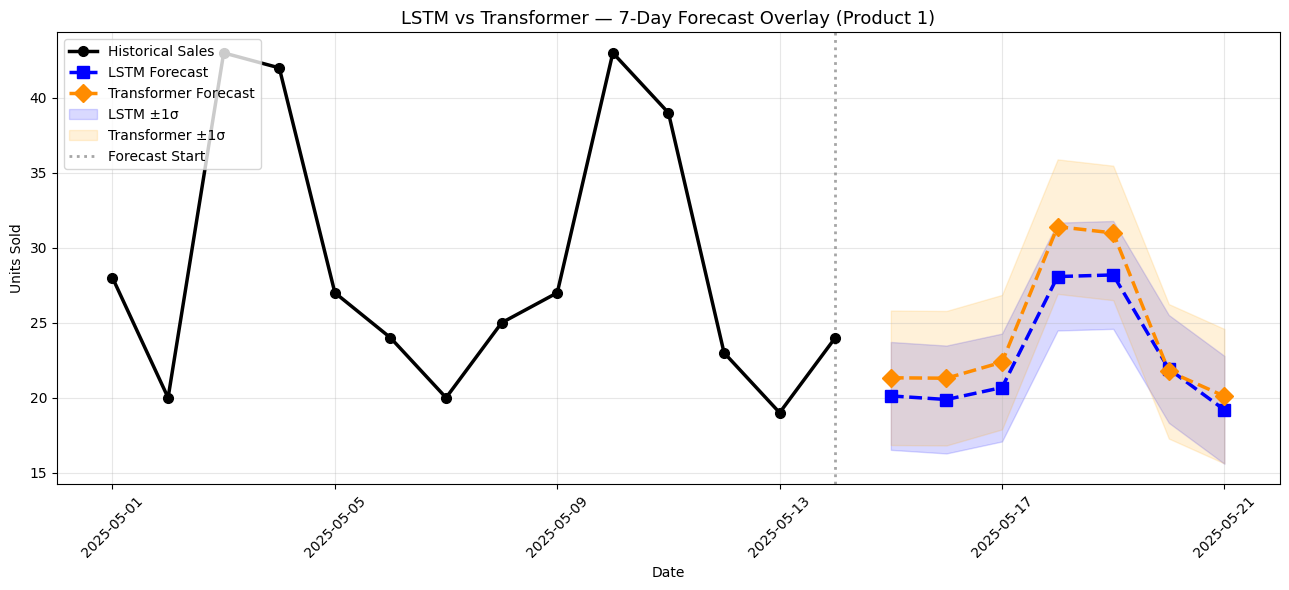

Saved 'forecast_overlay.png'


In [25]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(recent_dates, recent_sales, 'k-o', lw=2.5, label='Historical Sales', ms=7, zorder=5)
ax.plot(future_dates, lstm_forecasts, 'b--s',  lw=2.5, label='LSTM Forecast',        ms=9)
ax.plot(future_dates, tfm_forecasts,  '--D',   lw=2.5, label='Transformer Forecast', ms=9,
        color='darkorange')

# Confidence bands
ls = np.std(lstm_forecasts)
ts = np.std(tfm_forecasts)
ax.fill_between(future_dates,
                [f-ls for f in lstm_forecasts], [f+ls for f in lstm_forecasts],
                alpha=0.15, color='blue',       label='LSTM ±1σ')
ax.fill_between(future_dates,
                [f-ts for f in tfm_forecasts],  [f+ts for f in tfm_forecasts],
                alpha=0.15, color='orange',     label='Transformer ±1σ')

ax.axvline(x=product_df['date'].max(), color='gray', linestyle=':', lw=2,
           alpha=0.7, label='Forecast Start')

ax.set_title('LSTM vs Transformer — 7-Day Forecast Overlay (Product 1)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Units Sold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 'forecast_overlay.png'")

## 19. Cross-Product R² Comparison

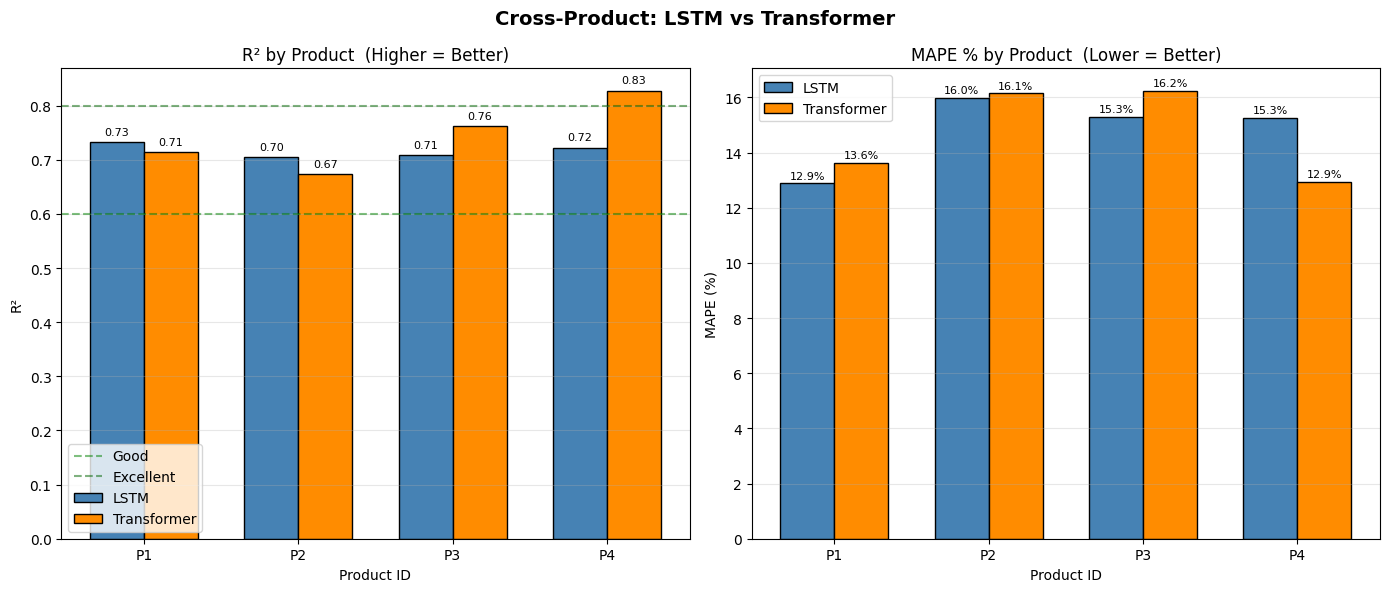

Saved 'cross_product_comparison.png'


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

products = [1, 2, 3, 4]
x_pos    = np.arange(len(products))
width    = 0.35

lstm_r2s = lstm_results_df['R2'].values
tfm_r2s  = tfm_results_df['R2'].values
lstm_mapes = lstm_results_df['MAPE'].values
tfm_mapes  = tfm_results_df['MAPE'].values

# R2 by product
b1 = axes[0].bar(x_pos - width/2, lstm_r2s, width, label='LSTM',        color='steelblue',  edgecolor='black')
b2 = axes[0].bar(x_pos + width/2, tfm_r2s,  width, label='Transformer', color='darkorange', edgecolor='black')
axes[0].set_title('R² by Product  (Higher = Better)')
axes[0].set_xlabel('Product ID'); axes[0].set_ylabel('R²')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels([f'P{p}' for p in products])
axes[0].axhline(y=0.6, color='green',     linestyle='--', alpha=0.5, label='Good')
axes[0].axhline(y=0.8, color='darkgreen', linestyle='--', alpha=0.5, label='Excellent')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(list(b1)+list(b2), list(lstm_r2s)+list(tfm_r2s)):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# MAPE by product
b3 = axes[1].bar(x_pos - width/2, lstm_mapes, width, label='LSTM',        color='steelblue',  edgecolor='black')
b4 = axes[1].bar(x_pos + width/2, tfm_mapes,  width, label='Transformer', color='darkorange', edgecolor='black')
axes[1].set_title('MAPE % by Product  (Lower = Better)')
axes[1].set_xlabel('Product ID'); axes[1].set_ylabel('MAPE (%)')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels([f'P{p}' for p in products])
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
for bar, v in zip(list(b3)+list(b4), list(lstm_mapes)+list(tfm_mapes)):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Cross-Product: LSTM vs Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_product_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 'cross_product_comparison.png'")

# Final Comparative Summary and Analytical Conclusion

This notebook represents the second major analytical extension of the Prisight forecasting framework and focuses on comparative deep learning analysis between recurrent neural networks and Transformer-based sequence learning for retail demand forecasting.

The primary objective of this notebook was to study the forecasting behavior, temporal learning capability, sequence dependency understanding, computational efficiency, and prediction stability of two major architectures:

1. Long Short-Term Memory (LSTM)
2. Transformer Architecture

The implementation was designed using long-term synthetic retail sales data incorporating:

- seasonal demand variations,
- trend continuation,
- cyclic weekly behavior,
- rolling demand momentum,
- discount-driven sales changes,
- and pricing influence.

Extensive feature engineering was performed to improve sequence learning capability. The forecasting pipeline incorporated lag-based sequential features, rolling averages, cyclic sine-cosine encoding, pricing relationships, discount elasticity, and demand momentum indicators to provide both recurrent and attention-based architectures with rich temporal information.

The notebook demonstrates a complete deep learning forecasting workflow beginning from synthetic data generation and preprocessing to sequence preparation, model implementation, training, evaluation, visualization, and future forecasting.

The LSTM architecture demonstrated stable sequential forecasting capability and strong long-term dependency learning through recurrent memory-based sequence processing. The model effectively captured historical temporal patterns and generated smooth sequential forecasts for retail demand prediction.

The Transformer architecture introduced attention-driven sequence learning into the Prisight ecosystem. Unlike recurrent architectures, the Transformer model processes sequence relationships using self-attention mechanisms, enabling improved long-range dependency understanding and parallel sequence learning.

The Transformer implementation utilized:

- Multi-Head Attention,
- Layer Normalization,
- Feed Forward Networks,
- and Dense Forecasting Layers

to analyze temporal dependencies across sequence windows more efficiently than traditional recurrent architectures.

Comparative analysis between the two architectures was performed using multiple forecasting metrics including:

- Root Mean Squared Error (RMSE),
- Mean Absolute Error (MAE),
- Mean Absolute Percentage Error (MAPE),
- and Coefficient of Determination (R² Score).

Additional visualization-based evaluations included:

- actual vs predicted forecasting curves,
- residual analysis,
- scatter regression comparison,
- sequential forecast overlays,
- and comparative performance visualization.

The notebook also implemented rolling-window future forecasting for generating multi-step future demand predictions. This enabled evaluation of sequential continuity and future temporal stability across both architectures.

Key observations from this analytical study include:

- LSTM architectures effectively learn sequential retail demand dependencies through recurrent memory mechanisms,
- Transformer architectures improve long-range temporal understanding through attention-based sequence relationships,
- cyclic feature encoding significantly improves temporal continuity learning,
- engineered sequential features improve forecasting realism,
- attention mechanisms improve contextual sequence learning,
- and Transformer-based forecasting demonstrates strong scalability for extended sequence analysis.

This notebook establishes the attention-learning benchmark within the Prisight forecasting ecosystem and serves as Notebook 2 in the analytical research series.

Together with Notebook 1, this implementation expands the Prisight framework from traditional recurrent forecasting approaches toward modern attention-driven deep learning architectures for intelligent retail demand forecasting.

Overall, this notebook demonstrates a practical implementation and analytical comparison between recurrent sequence learning and Transformer-based attention learning for advanced retail demand forecasting applications within the Prisight project.